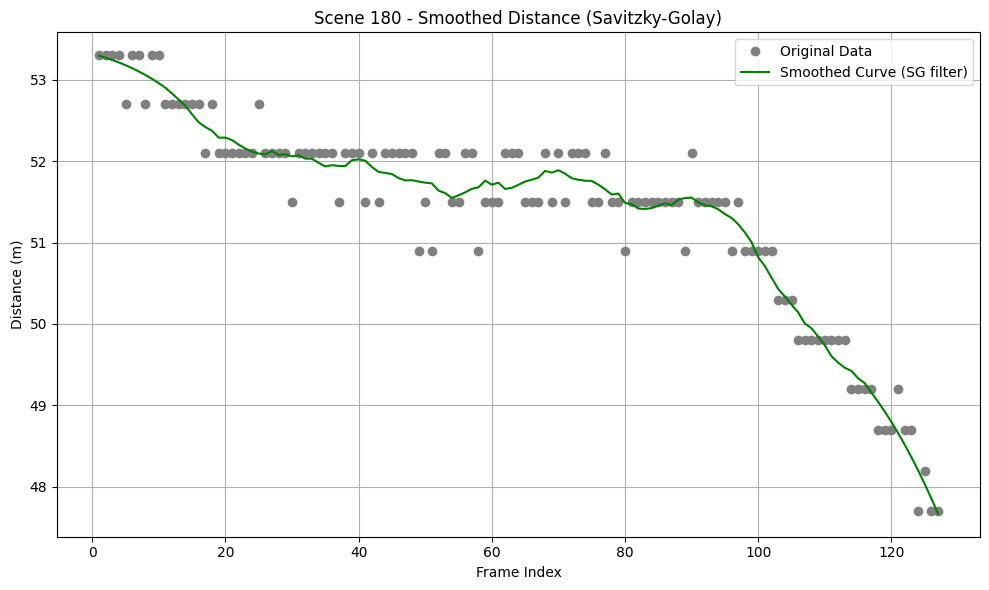

In [4]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# ---------- 入力 ----------
json_path = "./testdistance_estimates.json"
scene_id = "180"

# ---------- データ読み込み ----------
with open(json_path, encoding="utf-8") as f:
    all_data = json.load(f)

frame_data = all_data[scene_id]
frame_ids = sorted(frame_data.keys())
x = np.array([int(fid.replace("frame_", "")) for fid in frame_ids])
y = np.array([frame_data[fid] for fid in frame_ids])

# ---------- Savitzky-Golayフィルター適用 ----------
# window_length は奇数、polyorder は多項式の次数
window_length = 21 if len(y) >= 21 else (len(y) // 2 * 2 + 1)
polyorder = 3 if len(y) >= 4 else 2
y_smooth = savgol_filter(y, window_length, polyorder)

# ---------- 描画 ----------
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'o', color='gray', label='Original Data')
plt.plot(x, y_smooth, '-', color='green', label='Smoothed Curve (SG filter)')
plt.title(f"Scene {scene_id} - Smoothed Distance (Savitzky-Golay)")
plt.xlabel("Frame Index")
plt.ylabel("Distance (m)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# ---------- 設定 ----------
INPUT_JSON = "./testdistance_estimates_smoothed.json"
OUTPUT_JSON = "./test.json"
GRAPH_DIR = "./smoothed_graphs"
os.makedirs(GRAPH_DIR, exist_ok=True)

# ---------- 入力読み込み ----------
with open(INPUT_JSON, encoding="utf-8") as f:
    all_data = json.load(f)

# ---------- 出力用データ ----------
smoothed_data = {}

# ---------- 各シーン処理 ----------
for scene_id, frame_dict in all_data.items():
    frame_keys = sorted(frame_dict.keys())
    x = np.array([int(fid.replace("frame_", "")) for fid in frame_keys])
    y = np.array([frame_dict[fid] for fid in frame_keys])

    # Savitzky-Golay フィルター適用（ウィンドウサイズは調整）
    if len(y) >= 5:
        window_length = min(len(y) // 2 * 2 + 1, 25)  # 奇数に制限
        polyorder = 3 if window_length >= 5 else 2
        y_smooth = savgol_filter(y, window_length, polyorder)
    else:
        y_smooth = y  # データ点が少なすぎる場合はそのまま

    # 辞書に保存（元のkeyに対応）
    smoothed_data[scene_id] = {
        frame_keys[i]: float(round(y_smooth[i], 4)) for i in range(len(frame_keys))
    }

    # グラフ描画・保存
    plt.figure(figsize=(10, 6))
    plt.plot(x, y, 'o', color='gray', label='Original')
    plt.plot(x, y_smooth, '-', color='green', label='Smoothed')
    plt.title(f"Scene {scene_id} - Smoothed Distance")
    plt.xlabel("Frame Index")
    plt.ylabel("Distance (m)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(GRAPH_DIR, f"scene{scene_id}.png"))
    plt.close()

# ---------- 新しい JSON 保存 ----------
with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(smoothed_data, f, ensure_ascii=False, indent=2)

print("✅ 平滑化完了：JSON保存 ＆ グラフ出力完了")


✅ 平滑化完了：JSON保存 ＆ グラフ出力完了


In [8]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# ---------- 設定 ----------
INPUT_JSON = "./test.json"
GRAPH_DIR = "./spline_graphs_only"
os.makedirs(GRAPH_DIR, exist_ok=True)

# ---------- データ読み込み ----------
with open(INPUT_JSON, encoding="utf-8") as f:
    all_data = json.load(f)

# ---------- 各シーンに対してグラフ描画 ----------
for scene_id, frame_dict in all_data.items():
    frame_keys = sorted(frame_dict.keys())
    x = np.array([int(k.replace("frame_", "")) for k in frame_keys])
    y = np.array([frame_dict[k] for k in frame_keys])

    if len(x) >= 4:
        # 高密度スプライン補間
        x_smooth = np.linspace(x.min(), x.max(), len(x)*5)
        spline = make_interp_spline(x, y, k=3)
        y_smooth = spline(x_smooth)

        # 描画
        plt.figure(figsize=(10, 6))
        plt.plot(x, y, 'o', color='gray', label='Original Data')
        plt.plot(x_smooth, y_smooth, '-', color='green', label='Smoothed Distance')
        plt.title(f"Scene {scene_id} - Smoothed Distance")
        plt.xlabel("Frame Index")
        plt.ylabel("Distance (m)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(GRAPH_DIR, f"scene{scene_id}.png"))
        plt.close()

print("✅ 全シーンの滑らかなスプライン距離グラフを保存しました")


✅ 全シーンの滑らかなスプライン距離グラフを保存しました
